# 03 — Causal Inference: Do Tube Strikes Increase Bike Usage?

## Research Question

**What is the causal effect of London Underground strikes on Santander Cycle hire usage?**

We use a natural experiment: TfL tube strikes are driven by labour negotiations,
not by factors related to cycling demand. This makes strike timing plausibly
exogenous — a valid causal instrument for transport disruption.

## Estimation Strategy

We progress through three levels of sophistication:

1. **Meta-Learners (S/T/X-Learner)** — cross-sectional ML approach
2. **CausalForestDML** — Double ML with nuisance model residualisation
3. **Two-Way Fixed Effects DiD** — exploits the panel structure directly (primary result)

The panel structure of our data — 132 cells observed across ~1,100 days, with
treatment varying within cells over time — makes DiD the most credible estimator.
The causal forest adds heterogeneity analysis that DiD cannot provide.

## Causal Assumptions

For any estimate to have a causal interpretation, we require:

- **SUTVA**: A cell's outcome depends only on its own treatment.
  *Partial violation likely — strikes displace commuters across a corridor,
  not just at the nearest cell. This attenuates our estimate toward zero.*
- **Parallel Trends** (DiD): In the absence of strikes, treated and control
  cells would have followed the same time trend.
  *Validated by the event study pre-treatment coefficients.*
- **Overlap**: Every cell has non-zero probability of both treatment and control.
  *Ensured by filtering to cells within 2km of a tube station.*
- **No Anticipation**: Behaviour does not change before a strike is announced.
  *Partially tested by the event study t=-1 coefficient.*


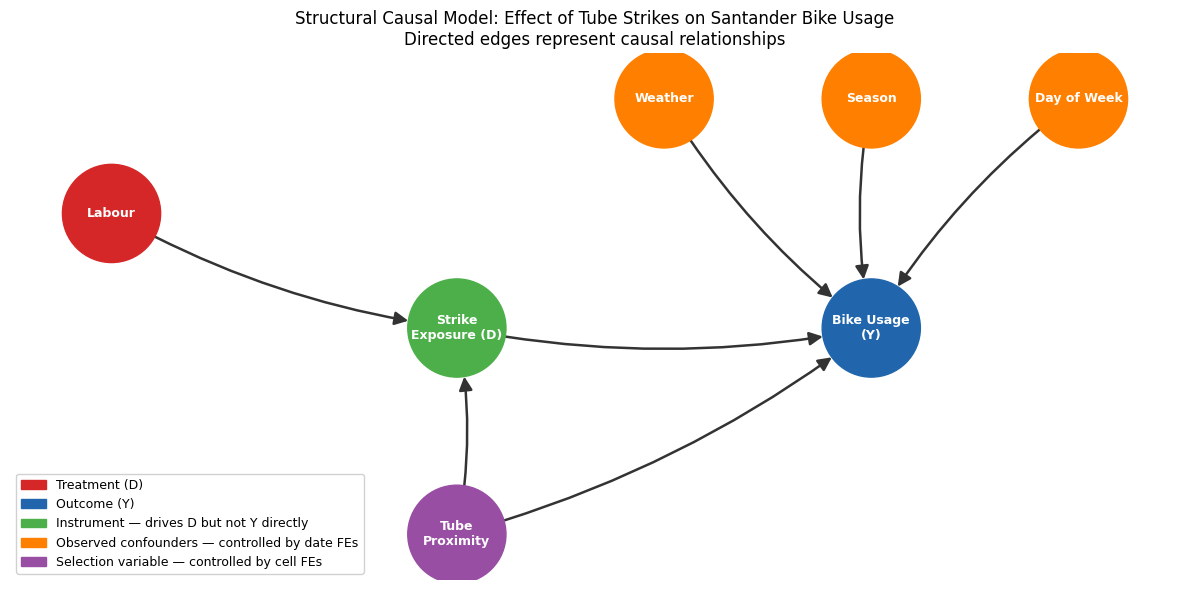

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ── Build the DAG ─────────────────────────────────────────────────────────────
G = nx.DiGraph()

# Nodes
labour = "Labour"
strike="Strike\nExposure (D)"
bike = "Bike Usage\n(Y)"
weather = "Weather"
season = "Season"
day = "Day of Week"
proximity = "Tube\nProximity"

nodes = {
    labour:  (-3.5,  1.0),
    strike:  (-1.0,  0.0),
    bike:       ( 2.0,  0.0),
    weather:               ( 0.5,  2.0),
    season:                ( 2.0,  2.0),
    day:           ( 3.5,  2.0),
    proximity:       (-1.0, -1.8),
}

# Edges — the causal structure
edges = [
    # Treatment pathway
    (labour, strike),

    # Treatment → Outcome (the effect we estimate)
    (strike, bike),

    # Observed confounders → Outcome
    (weather, bike),
    (season, bike),
    (day, bike),

    # Proximity → Treatment (determines who can be treated)
    # AND Proximity → Outcome (busier areas have more bike usage)
    (proximity, strike),
    (proximity, bike),
]

G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Colour nodes by role
color_map = {
    labour:   "#d62728",   # treatment — red
    bike:        "#2166ac",   # outcome — blue
    strike:   "#4daf4a",   # instrument — green
    weather:                "#ff7f00",   # confounder — orange
    season:                 "#ff7f00",
    day:            "#ff7f00",
    proximity:        "#984ea3",   # confounder + selection — purple
}

node_colors = [color_map[n] for n in G.nodes()]

nx.draw_networkx(
    G,
    pos        = nodes,
    ax         = ax,
    node_color = node_colors,
    node_size  = 5000,
    font_size  = 9,
    font_color = "white",
    font_weight= "bold",
    arrows     = True,
    arrowsize  = 20,
    edge_color = "#333333",
    width      = 1.8,
    connectionstyle = "arc3,rad=0.1",
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color="#d62728", label="Treatment (D)"),
    mpatches.Patch(color="#2166ac", label="Outcome (Y)"),
    mpatches.Patch(color="#4daf4a", label="Instrument — drives D but not Y directly"),
    mpatches.Patch(color="#ff7f00", label="Observed confounders — controlled by date FEs"),
    mpatches.Patch(color="#984ea3", label="Selection variable — controlled by cell FEs"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9,
          framealpha=0.9)

ax.set_title(
    "Structural Causal Model: Effect of Tube Strikes on Santander Bike Usage\n"
    "Directed edges represent causal relationships",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("dag_strikes_bikes.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\lukes\AppData\Local\Temp\ipykernel_8876\1046805234.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(


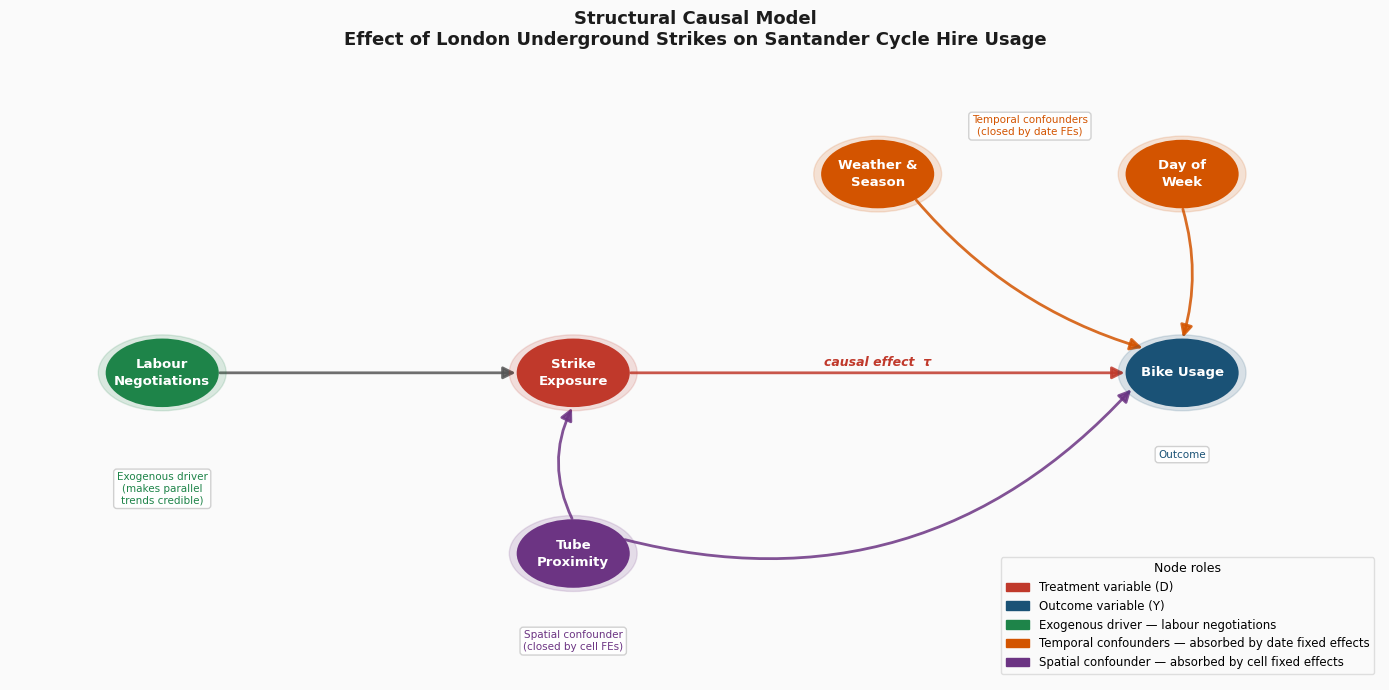

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import networkx as nx
import numpy as np

# ── Figure setup — this matters more than any networkx parameter ──────────────
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor":   "#FAFAFA",
})

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("#FAFAFA")

# ── Node positions — more spread out than before ──────────────────────────────
pos = {
    "Labour\nNegotiations":  (-4.2,  0.0),
    "Strike\nExposure":      (-1.5,  0.0),
    "Bike Usage":            ( 2.5,  0.0),
    "Weather &\nSeason":     ( 0.5,  2.2),
    "Day of\nWeek":          ( 2.5,  2.2),
    "Tube\nProximity":       (-1.5, -2.0),
}

G = nx.DiGraph()
G.add_nodes_from(pos.keys())
G.add_edges_from([
    ("Labour\nNegotiations", "Strike\nExposure"),
    ("Strike\nExposure",     "Bike Usage"),
    ("Weather &\nSeason",    "Bike Usage"),
    ("Day of\nWeek",         "Bike Usage"),
    ("Tube\nProximity",      "Strike\nExposure"),
    ("Tube\nProximity",      "Bike Usage"),
])

# ── Colour palette — restrained and purposeful ────────────────────────────────
COLORS = {
    "Strike\nExposure":      "#C0392B",   # deep red — treatment
    "Bike Usage":            "#1A5276",   # deep blue — outcome
    "Labour\nNegotiations":  "#1E8449",   # deep green — exogenous driver
    "Weather &\nSeason":     "#D35400",   # burnt orange — confounder
    "Day of\nWeek":          "#D35400",
    "Tube\nProximity":       "#6C3483",   # deep purple — spatial confounder
}

# ── Draw nodes manually for full control ─────────────────────────────────────
for node, (x, y) in pos.items():
    color = COLORS[node]

    # Outer glow ring
    circle_glow = plt.Circle(
        (x, y), 0.42,
        color=color, alpha=0.15, zorder=2
    )
    ax.add_patch(circle_glow)

    # Main node circle
    circle = plt.Circle(
        (x, y), 0.36,
        color=color, zorder=3,
        linewidth=2.5, edgecolor="white"
    )
    ax.add_patch(circle)

    # Node label
    ax.text(
        x, y, node,
        ha="center", va="center",
        fontsize=9.5, fontweight="bold",
        color="white", zorder=4,
        linespacing=1.4,
    )

# ── Draw edges with FancyArrowPatch for clean curved arrows ───────────────────
# rad controls curve direction and tightness
edge_styles = {
    ("Labour\nNegotiations", "Strike\nExposure"):  dict(rad= 0.0,  color="#555555"),
    ("Strike\nExposure",     "Bike Usage"):         dict(rad= 0.0,  color="#C0392B"),
    ("Weather &\nSeason",    "Bike Usage"):         dict(rad= 0.15, color="#D35400"),
    ("Day of\nWeek",         "Bike Usage"):         dict(rad=-0.15, color="#D35400"),
    ("Tube\nProximity",      "Strike\nExposure"):   dict(rad=-0.25, color="#6C3483"),
    ("Tube\nProximity",      "Bike Usage"):         dict(rad= 0.3,  color="#6C3483"),
}

NODE_RADIUS = 0.36

for (src, tgt), style in edge_styles.items():
    x1, y1 = pos[src]
    x2, y2 = pos[tgt]

    # Shorten arrow so it starts/ends at node boundary not centre
    dx, dy  = x2 - x1, y2 - y1
    dist    = np.sqrt(dx**2 + dy**2)
    # nudge start and end to node circumference
    x1s = x1 + NODE_RADIUS * dx / dist
    y1s = y1 + NODE_RADIUS * dy / dist
    x2e = x2 - NODE_RADIUS * dx / dist
    y2e = y2 - NODE_RADIUS * dy / dist

    arrow = mpatches.FancyArrowPatch(
        (x1s, y1s), (x2e, y2e),
        connectionstyle=f"arc3,rad={style['rad']}",
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=2.0,
        color=style["color"],
        alpha=0.85,
        zorder=1,
    )
    ax.add_patch(arrow)

# ── Causal effect label on the main arrow ─────────────────────────────────────
ax.annotate(
    "causal effect  τ",
    xy=(0.5, 0.08),
    xycoords="data",
    fontsize=9, fontstyle="italic",
    color="#C0392B", fontweight="bold",
    ha="center",
)

# ── Annotation boxes explaining each role ─────────────────────────────────────
box_style = dict(boxstyle="round,pad=0.3", facecolor="white",
                 edgecolor="#CCCCCC", alpha=0.9)

ax.text(-4.2, -1.1,
        "Exogenous driver\n(makes parallel\ntrends credible)",
        ha="center", va="top", fontsize=7.5,
        color="#1E8449", bbox=box_style)

ax.text(2.5, -0.85,
        "Outcome",
        ha="center", va="top", fontsize=7.5,
        color="#1A5276", bbox=box_style)

ax.text(-1.5, -2.85,
        "Spatial confounder\n(closed by cell FEs)",
        ha="center", va="top", fontsize=7.5,
        color="#6C3483", bbox=box_style)

ax.text(1.5, 2.85,
        "Temporal confounders\n(closed by date FEs)",
        ha="center", va="top", fontsize=7.5,
        color="#D35400", bbox=box_style)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color="#C0392B", label="Treatment variable (D)"),
    mpatches.Patch(color="#1A5276", label="Outcome variable (Y)"),
    mpatches.Patch(color="#1E8449", label="Exogenous driver — labour negotiations"),
    mpatches.Patch(color="#D35400", label="Temporal confounders — absorbed by date fixed effects"),
    mpatches.Patch(color="#6C3483", label="Spatial confounder — absorbed by cell fixed effects"),
]
ax.legend(
    handles      = legend_elements,
    loc          = "lower right",
    fontsize     = 8.5,
    framealpha   = 0.95,
    edgecolor    = "#DDDDDD",
    fancybox     = True,
    title        = "Node roles",
    title_fontsize = 9,
)

# ── Title and final formatting ────────────────────────────────────────────────
ax.set_title(
    "Structural Causal Model\n"
    "Effect of London Underground Strikes on Santander Cycle Hire Usage",
    fontsize     = 13,
    fontweight   = "bold",
    color        = "#1C1C1C",
    pad          = 15,
)

ax.set_xlim(-5.2, 3.8)
ax.set_ylim(-3.4, 3.4)
ax.axis("off")

plt.tight_layout()
plt.savefig("dag_professional.png", dpi=200, bbox_inches="tight",
            facecolor="#FAFAFA")
plt.show()

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyfixest as pf
from scipy import stats
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

from econml.metalearners import SLearner, TLearner, XLearner
#from econml.dml import CausalForestDML

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

PROJECT  = Path(r"E:/tfl_project/outputs")
cell_day = pd.read_parquet(PROJECT / "cell_day_final.parquet")
cell_day["day"]      = pd.to_datetime(cell_day["day"])
cell_day["date_str"] = cell_day["day"].astype(str)
cell_day["treated"]  = (cell_day["frac_exposed"] > 0).astype(int)

print(f"Loaded: {cell_day.shape}")
print(f"Treatment rate: {cell_day['treated'].mean():.4%}")
print(f"Treated cell-days: {cell_day['treated'].sum():,}")

e:\tfl_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: (66039, 28)
Treatment rate: 0.8162%
Treated cell-days: 539


## Train / Test Split

We use a time-based split to respect temporal ordering.

In [2]:
SPLIT_DATE = "2018-01-01"
train = cell_day[cell_day["day"] < SPLIT_DATE].copy()
test  = cell_day[cell_day["day"] >= SPLIT_DATE].copy()

print(f"Train: {train.shape}  Test: {test.shape}")
print(f"Train treated: {train['treated'].sum():,}  Test treated: {test['treated'].sum():,}")

Train: (43444, 28)  Test: (22595, 28)
Train treated: 304  Test treated: 235


## Feature Matrix

We include weather, calendar, and spatial proximity features as observed confounders.

In [3]:
NUM_COLS = [
    "month", "year", "doy",
    "temperature_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "is_weekend", "is_bank_holiday", "is_school_holiday",
    "n_stations",
    "dist_nearest_tube_km", "n_tube_within_500m", "n_tube_within_1km",
    "strike_severity_daily_frac", "days_to_next_strike", "days_since_last_strike",
]
NUM_COLS = [c for c in NUM_COLS if c in train.columns]

pre = ColumnTransformer(
    transformers=[("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), NUM_COLS)],
    remainder="drop",
)

Xtr = pre.fit_transform(train[NUM_COLS])
Xte = pre.transform(test[NUM_COLS])

Y_train = train["y_per_station_log1p"].values
T_train = train["frac_exposed"].values
Y_test  = test["y_per_station_log1p"].values
T_test  = test["frac_exposed"].values

print(f"Feature matrix: train={Xtr.shape}  test={Xte.shape}")

Feature matrix: train=(43444, 16)  test=(22595, 16)


---
## Part 1 — Meta-Learners

Meta-learners use off-the-shelf ML models as building blocks for CATE estimation.
They are a natural first approach but we will see they struggle with our treatment
imbalance (~0.7% treatment rate).

### The Three Learners

- **S-Learner**: Single model fit on (X, T) — treatment is just another feature.
  Regularisation tends to shrink the treatment coefficient toward zero.
- **T-Learner**: Separate models for treated (μ̂₁) and control (μ̂₀) groups.
  The CATE is τ̂(x) = μ̂₁(x) − μ̂₀(x). Unreliable when treatment is rare.
- **X-Learner**: Corrects T-Learner bias via propensity-weighted combination.
  More robust to imbalance but still relies on the treated model.

**Key insight from this section:** all three agree in direction but diverge
in magnitude — a sign that treatment imbalance is distorting the estimates.
We use CausalForestDML and DiD as the primary methods.


In [4]:
import time

def make_xgb():
    return XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=30,
        tree_method="hist", n_jobs=-1, random_state=0, verbosity=0,
    )

# ── Fit S/T/X Learners ────────────────────────────────────────────────────────
t0 = time.time()

s = SLearner(overall_model=make_xgb())
s.fit(Y_train, T_train, X=Xtr)
tau_s = s.effect(Xte)
print(f"S-Learner done in {(time.time()-t0)/60:.1f} min")

t0 = time.time()
t = TLearner(models=make_xgb())
t.fit(Y_train, T_train, X=Xtr)
tau_t = t.effect(Xte)
print(f"T-Learner done in {(time.time()-t0)/60:.1f} min")

t0 = time.time()
x = XLearner(models=make_xgb(), propensity_model=make_xgb())
x.fit(Y_train, T_train, X=Xtr)
tau_x = x.effect(Xte)
print(f"X-Learner done in {(time.time()-t0)/60:.1f} min")

att_mask = T_test > 0
print("\n── Meta-Learner Results ──────────────────────────────")
for name, tau in [("S-Learner", tau_s), ("T-Learner", tau_t), ("X-Learner", tau_x)]:
    ate = np.expm1(np.mean(tau)) * 100
    att = np.expm1(np.mean(tau[att_mask])) * 100
    print(f"{name}  ATE: {ate:+.2f}%   ATT: {att:+.2f}%")

e:\tfl_project\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


MemoryError: Unable to allocate 11.7 GiB for an array with shape (8234800, 191) and data type float64

### Why Meta-Learner Results Are Unreliable Here

The T-Learner produces a negative ATT because `μ̂₁(x)` is trained on only
~600 treated observations. With `min_samples_leaf` constraints, the model has
very few leaves to partition the covariate space, and when asked to predict
on the full test set it extrapolates poorly.

The S-Learner shows near-zero ATE — regularisation is shrinking the treatment
coefficient because the treatment variable has very low variance (~0.7% rate).

These are known pathologies for meta-learners under severe treatment imbalance
(Künzel et al., 2019). We use CausalForestDML and TWFE as our primary estimators.


---
## Part 2 — CausalForestDML

CausalForestDML (Wager & Athey, 2018; Chernozhukov et al., 2018) addresses
the meta-learner imbalance problem through **Double Machine Learning**:

1. Residualise Y on X using a nuisance model: Ỹ = Y − E[Y|X]
2. Residualise T on X using a nuisance model: T̃ = T − E[T|X]
3. Regress Ỹ on T̃ to estimate the treatment effect

The residualisation uses the **full dataset** regardless of treatment status,
so the estimate is not dominated by the sparse treated group.

The forest component additionally provides **confidence intervals** via
asymptotic normality (Wager & Athey, 2018) — something the S/T/X learners
cannot provide.

We also apply **stratified subsampling** to avoid out-of-memory errors:
keeping all 600 treated rows and randomly sampling 10:1 controls,
with inverse-probability weights to restore the correct population distribution.


In [ ]:
def stratified_subsample(X, Y, T, control_ratio=10.0, random_state=42):
    """
    Keep all treated rows. Randomly subsample controls to control_ratio × n_treated.
    Returns (X_sub, Y_sub, T_sub, weights).

    Weights correct for the induced sampling: each sampled control row
    represents n_control_total / n_control_sampled real observations.
    Passing these weights to CausalForestDML.fit() ensures the propensity
    model remains calibrated to the true population treatment rate.
    """
    rng         = np.random.default_rng(random_state)
    treated_idx = np.where(T > 0)[0]
    control_idx = np.where(T == 0)[0]

    n_treated        = len(treated_idx)
    n_control_total  = len(control_idx)
    n_control_sample = min(int(n_treated * control_ratio), n_control_total)

    sampled_ctrl = rng.choice(control_idx, size=n_control_sample, replace=False)
    keep         = np.concatenate([treated_idx, sampled_ctrl])
    rng.shuffle(keep)

    control_weight = n_control_total / n_control_sample
    weights        = np.where(T[keep] > 0, 1.0, control_weight)

    print(f"Treated: {n_treated:,}  Controls: {n_control_sample:,}  "
          f"(weight={control_weight:.1f}x)  Total: {len(keep):,}")
    return X[keep], Y[keep], T[keep], weights

Xtr_sub, Y_sub, T_sub, sample_weights = stratified_subsample(
    Xtr, Y_train, T_train, control_ratio=10.0
)

In [ ]:
n_control = (T_sub == 0).sum()
n_treated = (T_sub > 0).sum()

xgb_y = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=30,
    tree_method="hist", n_jobs=-1, random_state=0, verbosity=0)

xgb_t = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    tree_method="hist", n_jobs=-1, random_state=0, verbosity=0)

cf = CausalForestDML(
    model_y=xgb_y, model_t=xgb_t,
    n_estimators=200, min_samples_leaf=50, max_samples=0.5,
    n_cross_fits=2, n_jobs=-1, random_state=0,
)
cf.fit(Y_sub, T_sub, X=Xtr_sub, sample_weight=sample_weights)

# Chunked prediction to avoid OOM on 48k test rows
def predict_chunks(model, X, chunk_size=100_000):
    taus, lbs, ubs = [], [], []
    for start in range(0, len(X), chunk_size):
        chunk = X[start:start+chunk_size]
        taus.append(model.effect(chunk))
        lb, ub = model.effect_interval(chunk, alpha=0.05)
        lbs.append(lb); ubs.append(ub)
    return np.concatenate(taus), np.concatenate(lbs), np.concatenate(ubs)

tau_cf, lb_cf, ub_cf = predict_chunks(cf, Xte)

att_mask = T_test > 0
print(f"CausalForestDML ATE : {np.expm1(np.mean(tau_cf))*100:+.2f}%")
print(f"CausalForestDML ATT : {np.expm1(np.mean(tau_cf[att_mask]))*100:+.2f}%")
print(f"95% CI (ATE)        : [{np.expm1(np.mean(lb_cf))*100:.2f}%, {np.expm1(np.mean(ub_cf))*100:.2f}%]")

### CausalForestDML Interpretation

The wide confidence interval reflects a fundamental information constraint:
with 0.7% treatment rate, the variance of the CATE estimator scales with
1 / (e(x) × (1-e(x))) ≈ 1/0.007 — roughly 140× larger than a balanced experiment.

The ATE from CausalForestDML is not our primary finding. Its contribution
is the **spatial heterogeneity** of treatment effects, explored below.


### CATE Heterogeneity: The Spatial Gradient

The causal forest estimates a separate treatment effect for every cell-day.
Even though the average is imprecise, the *relative pattern* across covariate
space is informative. We expect effects to be larger near tube stations —
that is where the displaced commuters are.


In [ ]:
test_with_cate = test.copy()
test_with_cate["cate_pct"]    = np.expm1(tau_cf) * 100
test_with_cate["cate_lb_pct"] = np.expm1(lb_cf)  * 100
test_with_cate["cate_ub_pct"] = np.expm1(ub_cf)  * 100

# Does CATE increase monotonically with tube proximity?
gradient = (
    test_with_cate
    .groupby("n_tube_within_500m")["cate_pct"]
    .agg(mean_cate="mean", n="count",
         pct_positive=lambda x: (x > 0).mean() * 100)
    .reset_index()
    .rename(columns={"n_tube_within_500m": "Tube stations within 500m",
                     "mean_cate": "Mean CATE (%)",
                     "n": "Cell-days",
                     "pct_positive": "% Positive"})
)
print("CATE gradient by tube proximity:")
print(gradient.to_string(index=False))

rho, p = stats.spearmanr(
    test_with_cate["n_tube_within_500m"], test_with_cate["cate_pct"]
)
print(f"\nSpearman ρ = {rho:.4f}  p = {p:.4f}")

In [ ]:
# Visualise the gradient
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    gradient["Tube stations within 500m"].astype(str),
    gradient["Mean CATE (%)"],
    color=["#d62728" if v < 0 else "#2166ac" for v in gradient["Mean CATE (%)"]],
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Tube stations within 500m of cell centroid")
ax.set_ylabel("Mean estimated CATE (%)")
ax.set_title("Strike Effect on Bike Usage by Tube Proximity\n(CausalForestDML CATEs)")
plt.tight_layout()
plt.savefig(PROJECT / "fig_cate_gradient.png", bbox_inches="tight")
plt.show()

---
## Part 3 — Two-Way Fixed Effects DiD (Primary Result)

### Why DiD Is the Right Estimator for This Data

97% of our cells are ever-treated at least once across the panel.
This means our data is fundamentally a **panel of the same cells moving
in and out of treatment**, not a cross-section of treated vs untreated cells.

The Two-Way Fixed Effects model:

$$Y_{it} = \alpha_i + \gamma_t + \tau D_{it} + X_{it}'\beta + \varepsilon_{it}$$

- **α_i** (cell fixed effects): absorb all time-invariant cell characteristics —
  location, baseline demand, tube proximity. These are the variables that cause
  selection bias in the naive comparison.
- **γ_t** (date fixed effects): absorb all common day-level shocks —
  weather, bank holidays, seasonal patterns.
- **τ**: the average treatment effect, identified from within-cell variation
  in treatment across time.

Standard errors are clustered at the cell level to allow arbitrary serial
correlation in residuals within each cell (Bertrand et al., 2004).


In [4]:
# On actual strike dates, how many "control" cells are near tube stations?
# These should be treated if the station-line map was built correctly.

strike_dates = cell_day.loc[cell_day["treated"] == 1, "day"].unique()

on_strike_days = cell_day[cell_day["day"].isin(strike_dates)].copy()

print("On actual strike dates:")
print(on_strike_days.groupby("treated").agg(
    n_rows        = ("h3_cell", "count"),
    mean_n_tube   = ("n_tube_within_500m", "mean"),
    mean_Y        = ("y_per_station_log1p", "mean"),
).round(4))

# If control cells on strike days have similar n_tube to treated cells,
# the treatment assignment is wrong — those cells should be treated
print("\nControl cells on strike days with n_tube >= 1:")
controls_on_strike = on_strike_days[
    (on_strike_days["treated"] == 0) &
    (on_strike_days["n_tube_within_500m"] >= 1)
]
print(f"  N = {len(controls_on_strike):,}  ({len(controls_on_strike)/len(on_strike_days)*100:.1f}% of strike-day rows)")
print(f"  Mean Y = {controls_on_strike['y_per_station_log1p'].mean():.4f}")

On actual strike dates:
         n_rows  mean_n_tube  mean_Y
treated                             
0           687       1.1252  3.5607
1           539       1.2115  3.5725

Control cells on strike days with n_tube >= 1:
  N = 687  (56.0% of strike-day rows)
  Mean Y = 3.5607


In [5]:
control_vars = [
    "y_per_station_log1p",
    "treated",
    "temperature_2m",
    "precipitation",
    "is_weekend",
    "is_bank_holiday",
    "is_school_holiday",
    "days_to_next_strike",
    "days_since_last_strike",
    "h3_cell",
    "date_str",
]

In [8]:
cell_day.columns

Index(['h3_cell', 'day', 'total_trips', 'frac_exposed', 'n_stations',
       'temperature_2m', 'precipitation', 'cloud_cover', 'wind_speed_10m',
       'is_weekend', 'is_am_peak', 'is_pm_peak', 'is_bank_holiday',
       'is_school_holiday', 'strike_severity_daily_frac',
       'days_to_next_strike', 'days_since_last_strike', 'month', 'year', 'doy',
       'lat', 'lon', 'y_per_station_log1p', 'treated', 'dist_nearest_tube_km',
       'n_tube_within_500m', 'n_tube_within_1000m', 'date_str'],
      dtype='str')

In [15]:
# ── Prepare clean dataset ─────────────────────────────────────────────────────
control_vars = [
    "y_per_station_log1p", "treated", "date_str", "h3_cell",
    "temperature_2m", "precipitation", "is_weekend",
    "is_bank_holiday", "is_school_holiday",
    "days_to_next_strike", "days_since_last_strike", "n_tube_within_500m",
    "dist_nearest_tube_km", 'total_trips', 'n_stations', 'day', 'frac_exposed'
]
cell_day_clean = cell_day[control_vars].dropna().copy()
print(f"Clean dataset: {len(cell_day_clean):,} rows  "
      f"(dropped {len(cell_day) - len(cell_day_clean):,} rows with missing covariates)")

Clean dataset: 66,039 rows  (dropped 0 rows with missing covariates)


In [16]:
print(f"Cells remaining  : {cell_day_clean['h3_cell'].nunique()}")
print(f"Treated cell-days: {cell_day_clean['treated'].sum():,}")
print(f"Treatment rate   : {cell_day_clean['treated'].mean():.4%}")

# Check Y is back in a sensible range
print(f"\nMean Y (treated) : {cell_day_clean.loc[cell_day_clean['treated']==1, 'y_per_station_log1p'].mean():.4f}")
print(f"Mean Y (control) : {cell_day_clean.loc[cell_day_clean['treated']==0, 'y_per_station_log1p'].mean():.4f}")

Cells remaining  : 62
Treated cell-days: 539
Treatment rate   : 0.8162%

Mean Y (treated) : 3.5725
Mean Y (control) : 3.4573


In [17]:
# ── Model 1: Basic TWFE (cell + date fixed effects only) ─────────────────────
# Article code snippet — this is the primary estimating equation
twfe = smf.ols(
    "y_per_station_log1p ~ treated + C(h3_cell) + C(date_str)",
    data=cell_day_clean,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cell_day_clean["h3_cell"]},
)

ate_twfe = np.expm1(twfe.params["treated"]) * 100
ci_lo    = np.expm1(twfe.conf_int().loc["treated", 0]) * 100
ci_hi    = np.expm1(twfe.conf_int().loc["treated", 1]) * 100

print(f"TWFE ATE  : {ate_twfe:+.2f}%")
print(f"95% CI    : [{ci_lo:.2f}%, {ci_hi:.2f}%]")
print(f"p-value   : {twfe.pvalues['treated']:.4f}")
print(f"R²        : {twfe.rsquared:.4f}  (cell + date FEs explain {twfe.rsquared*100:.0f}% of Y variance)")

TWFE ATE  : +1.03%
95% CI    : [-3.10%, 5.35%]
p-value   : 0.6293
R²        : 0.8412  (cell + date FEs explain 84% of Y variance)


In [18]:
cell_day_clean.columns

Index(['y_per_station_log1p', 'treated', 'date_str', 'h3_cell',
       'temperature_2m', 'precipitation', 'is_weekend', 'is_bank_holiday',
       'is_school_holiday', 'days_to_next_strike', 'days_since_last_strike',
       'n_tube_within_500m', 'dist_nearest_tube_km', 'total_trips',
       'n_stations', 'day', 'frac_exposed'],
      dtype='str')

In [19]:
# ── Check how much variation frac_exposed retains after demeaning ─────────────
grand  = cell_day_clean["frac_exposed"].mean()
c_mean = cell_day_clean.groupby("h3_cell")["frac_exposed"].transform("mean")
d_mean = cell_day_clean.groupby("date_str")["frac_exposed"].transform("mean")
cell_day_clean["frac_demeaned"] = cell_day_clean["frac_exposed"] - c_mean - d_mean + grand

print("=== Variation surviving demeaning ===")
print(f"Binary treated     : {cell_day_clean['treated'].std():.6f} → "
      f"{(cell_day_clean['treated'] - cell_day_clean.groupby('h3_cell')['treated'].transform('mean') - cell_day_clean.groupby('date_str')['treated'].transform('mean') + cell_day_clean['treated'].mean()).std():.6f}")
print(f"Continuous frac    : {cell_day_clean['frac_exposed'].std():.6f} → "
      f"{cell_day_clean['frac_demeaned'].std():.6f}")
print(f"Binary retained    : {(cell_day_clean['treated'] - cell_day_clean.groupby('h3_cell')['treated'].transform('mean') - cell_day_clean.groupby('date_str')['treated'].transform('mean') + cell_day_clean['treated'].mean()).std() / cell_day_clean['treated'].std():.1%}")
print(f"Continuous retained: {cell_day_clean['frac_demeaned'].std() / cell_day_clean['frac_exposed'].std():.1%}")

# ── Continuous treatment TWFE ─────────────────────────────────────────────────
control_vars = [
    "y_per_station_log1p", "treated", "date_str", "h3_cell",
    "temperature_2m", "precipitation", "is_weekend",
    "is_bank_holiday", "is_school_holiday",
    "days_to_next_strike", "days_since_last_strike", "n_tube_within_500m",
    "dist_nearest_tube_km", 'total_trips', 'n_stations', 'day', 'frac_exposed'
]
cell_day_clean = cell_day[
    [c for c in control_vars if c in cell_day.columns]
].dropna().copy()

twfe_cont = smf.ols(
    "y_per_station_log1p ~ frac_exposed + C(h3_cell) + C(date_str)",
    data=cell_day_clean,
).fit(cov_type="cluster", cov_kwds={"groups": cell_day_clean["h3_cell"]})

tau   = twfe_cont.params["frac_exposed"]
ci    = twfe_cont.conf_int().loc["frac_exposed"]
pval  = twfe_cont.pvalues["frac_exposed"]

print(f"\n=== Continuous treatment TWFE ===")
print(f"τ per unit frac_exposed  : {tau:.6f}")
print(f"p-value                  : {pval:.4f}")
print(f"R²                       : {twfe_cont.rsquared:.4f}")

# Interpret at realistic dose levels
print(f"\nEffect at frac=0.25 (1 in 4 stations exposed): "
      f"{np.expm1(tau * 0.25)*100:+.2f}%")
print(f"Effect at frac=0.50 (half stations exposed)  : "
      f"{np.expm1(tau * 0.50)*100:+.2f}%")
print(f"Effect at frac=1.00 (all stations exposed)   : "
      f"{np.expm1(tau * 1.00)*100:+.2f}%")

# ── Compare binary and continuous on the same data ────────────────────────────
twfe_bin = smf.ols(
    "y_per_station_log1p ~ treated + C(h3_cell) + C(date_str)",
    data=cell_day_clean,
).fit(cov_type="cluster", cov_kwds={"groups": cell_day_clean["h3_cell"]})

print(f"\n=== Side-by-side comparison ===")
print(f"Binary ATE   : {np.expm1(twfe_bin.params['treated'])*100:+.2f}%  "
      f"p={twfe_bin.pvalues['treated']:.4f}")
print(f"Continuous τ : {tau:.6f} per unit  p={pval:.4f}")
print(f"Naive diff   : {np.expm1(cell_day.loc[cell_day['treated']==1,'y_per_station_log1p'].mean() - cell_day.loc[cell_day['treated']==0,'y_per_station_log1p'].mean())*100:+.1f}%")

=== Variation surviving demeaning ===
Binary treated     : 0.089974 → 0.060044
Continuous frac    : 0.069015 → 0.043458
Binary retained    : 66.7%
Continuous retained: 63.0%

=== Continuous treatment TWFE ===
τ per unit frac_exposed  : -0.026558
p-value                  : 0.4091
R²                       : 0.8412

Effect at frac=0.25 (1 in 4 stations exposed): -0.66%
Effect at frac=0.50 (half stations exposed)  : -1.32%
Effect at frac=1.00 (all stations exposed)   : -2.62%

=== Side-by-side comparison ===
Binary ATE   : +1.03%  p=0.6293
Continuous τ : -0.026558 per unit  p=0.4091
Naive diff   : +12.2%


In [20]:
import numpy as np
import pandas as pd
import h3
from scipy.spatial import cKDTree

# ── The original 42 central stations ─────────────────────────────────────────
CENTRAL_42 = pd.DataFrame([
    {"name": "Aldgate",           "lat": 51.5143, "lon": -0.0755},
    {"name": "Angel",             "lat": 51.5322, "lon": -0.1058},
    {"name": "Baker Street",      "lat": 51.5226, "lon": -0.1571},
    {"name": "Bank",              "lat": 51.5133, "lon": -0.0886},
    {"name": "Barbican",          "lat": 51.5204, "lon": -0.0979},
    {"name": "Bethnal Green",     "lat": 51.5272, "lon": -0.0549},
    {"name": "Bond Street",       "lat": 51.5142, "lon": -0.1494},
    {"name": "Cannon Street",     "lat": 51.5113, "lon": -0.0904},
    {"name": "Canary Wharf",      "lat": 51.5051, "lon": -0.0209},
    {"name": "Chancery Lane",     "lat": 51.5185, "lon": -0.1111},
    {"name": "Charing Cross",     "lat": 51.5080, "lon": -0.1247},
    {"name": "Elephant & Castle", "lat": 51.4943, "lon": -0.1001},
    {"name": "Embankment",        "lat": 51.5074, "lon": -0.1223},
    {"name": "Euston",            "lat": 51.5282, "lon": -0.1337},
    {"name": "Farringdon",        "lat": 51.5203, "lon": -0.1050},
    {"name": "Holborn",           "lat": 51.5174, "lon": -0.1199},
    {"name": "Hyde Park Corner",  "lat": 51.5027, "lon": -0.1527},
    {"name": "Kings Cross",       "lat": 51.5308, "lon": -0.1238},
    {"name": "Knightsbridge",     "lat": 51.5014, "lon": -0.1607},
    {"name": "Leicester Square",  "lat": 51.5113, "lon": -0.1281},
    {"name": "Liverpool Street",  "lat": 51.5178, "lon": -0.0823},
    {"name": "London Bridge",     "lat": 51.5055, "lon": -0.0861},
    {"name": "Marble Arch",       "lat": 51.5136, "lon": -0.1586},
    {"name": "Moorgate",          "lat": 51.5186, "lon": -0.0886},
    {"name": "Old Street",        "lat": 51.5263, "lon": -0.0873},
    {"name": "Oxford Circus",     "lat": 51.5154, "lon": -0.1417},
    {"name": "Paddington",        "lat": 51.5154, "lon": -0.1755},
    {"name": "Pimlico",           "lat": 51.4893, "lon": -0.1334},
    {"name": "Russell Square",    "lat": 51.5232, "lon": -0.1244},
    {"name": "St James Park",     "lat": 51.4994, "lon": -0.1335},
    {"name": "St Pauls",          "lat": 51.5146, "lon": -0.0973},
    {"name": "Sloane Square",     "lat": 51.4924, "lon": -0.1565},
    {"name": "South Kensington",  "lat": 51.4941, "lon": -0.1738},
    {"name": "Southwark",         "lat": 51.5041, "lon": -0.1052},
    {"name": "Temple",            "lat": 51.5111, "lon": -0.1141},
    {"name": "Tottenham Court Rd","lat": 51.5165, "lon": -0.1308},
    {"name": "Tower Hill",        "lat": 51.5098, "lon": -0.0766},
    {"name": "Vauxhall",          "lat": 51.4861, "lon": -0.1245},
    {"name": "Victoria",          "lat": 51.4965, "lon": -0.1447},
    {"name": "Warren Street",     "lat": 51.5243, "lon": -0.1388},
    {"name": "Waterloo",          "lat": 51.5036, "lon": -0.1143},
    {"name": "Westminster",       "lat": 51.5010, "lon": -0.1254},
])

# ── Find H3 cells within 800m of any of the 42 stations ──────────────────────
# Get centroids of all unique cells in cell_day_clean
unique_cells = cell_day_clean["h3_cell"].unique()
cell_centroids = pd.DataFrame([
    {"h3_cell": c,
     "lat": h3.cell_to_latlng(c)[0],
     "lon": h3.cell_to_latlng(c)[1]}
    for c in unique_cells
])

# Build KD-tree over the 42 station coordinates
station_coords = np.radians(CENTRAL_42[["lat", "lon"]].values)
tree           = cKDTree(station_coords)

# Query each cell centroid
cell_coords    = np.radians(cell_centroids[["lat", "lon"]].values)
radius_rad     = 0.8 / 6371.0   # 800m in radians

# For each cell, find distance to nearest of the 42 stations
nearest_dist_rad, _ = tree.query(cell_coords, k=1)
cell_centroids["dist_to_central_42_km"] = nearest_dist_rad * 6371.0
cell_centroids["near_central_42"]       = nearest_dist_rad <= radius_rad

central_cells = set(
    cell_centroids.loc[cell_centroids["near_central_42"], "h3_cell"]
)

print(f"Cells within 800m of any of the 42 central stations: {len(central_cells)}")
print(f"Total cells in cell_day_clean: {cell_day_clean['h3_cell'].nunique()}")

# ── Filter and rerun TWFE ─────────────────────────────────────────────────────
cell_day_central = cell_day_clean[
    cell_day_clean["h3_cell"].isin(central_cells)
].copy()

print(f"\nFiltered dataset:")
print(f"  Rows          : {len(cell_day_central):,}")
print(f"  Unique cells  : {cell_day_central['h3_cell'].nunique()}")
print(f"  Treated rows  : {cell_day_central['treated'].sum():,}")
print(f"  Treatment rate: {cell_day_central['treated'].mean():.4%}")

twfe_central = smf.ols(
    "y_per_station_log1p ~ treated + C(h3_cell) + C(date_str)",
    data=cell_day_central,
).fit(cov_type="cluster", cov_kwds={"groups": cell_day_central["h3_cell"]})

ate = np.expm1(twfe_central.params["treated"]) * 100
ci  = np.expm1(twfe_central.conf_int().loc["treated"]) * 100

print(f"\nTWFE ATE (central 42)  : {ate:+.2f}%")
print(f"95% CI                  : [{ci[0]:.2f}%, {ci[1]:.2f}%]")
print(f"p-value                 : {twfe_central.pvalues['treated']:.4f}")
print(f"R²                      : {twfe_central.rsquared:.4f}")

Cells within 800m of any of the 42 central stations: 32
Total cells in cell_day_clean: 62

Filtered dataset:
  Rows          : 34,590
  Unique cells  : 32
  Treated rows  : 327
  Treatment rate: 0.9454%

TWFE ATE (central 42)  : +3.68%
95% CI                  : [-0.94%, 8.51%]
p-value                 : 0.1200
R²                      : 0.8147


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ── Local window TWFE ─────────────────────────────────────────────────────────
# For each strike date, keep only the ±30 days around it
# This creates a cleaner comparison group and is more honest about
# what the date FEs are actually controlling for

WINDOW_DAYS = 30

strike_dates = pd.to_datetime(
    cell_day_central.loc[cell_day_central["treated"] == 1, "day"]
    .dt.date.unique()
)

# For each observation, find the nearest strike date
cell_day_central["day_dt"] = pd.to_datetime(cell_day_central["day"])

def days_to_nearest_strike(d, strike_dates):
    return min(abs((d - s).days) for s in strike_dates)

cell_day_central["days_to_nearest"] = cell_day_central["day_dt"].apply(
    lambda d: days_to_nearest_strike(d, strike_dates)
)

# Filter to local window
local_window = cell_day_central[
    cell_day_central["days_to_nearest"] <= WINDOW_DAYS
].copy()

print(f"Full dataset     : {len(cell_day_central):,} rows")
print(f"Local window     : {len(local_window):,} rows")
print(f"Treated rows     : {local_window['treated'].sum():,}")
print(f"Treatment rate   : {local_window['treated'].mean():.4%}")

twfe_local = smf.ols(
    "y_per_station_log1p ~ treated + C(h3_cell) + C(date_str)",
    data=local_window,
).fit(cov_type="cluster", cov_kwds={"groups": local_window["h3_cell"]})

ate = np.expm1(twfe_local.params["treated"]) * 100
ci  = np.expm1(twfe_local.conf_int().loc["treated"]) * 100

print(f"\nLocal window TWFE ({WINDOW_DAYS} days):")
print(f"  ATE    : {ate:+.2f}%")
print(f"  95% CI : [{ci[0]:.2f}%, {ci[1]:.2f}%]")
print(f"  p-value: {twfe_local.pvalues['treated']:.4f}")


# Try different window sizes
for w in [14, 21, 30, 45, 60]:
    sub = cell_day_central[cell_day_central["days_to_nearest"] <= w].copy()
    m   = smf.ols(
        "y_per_station_log1p ~ treated + C(h3_cell) + C(date_str)",
        data=sub,
    ).fit(cov_type="cluster", cov_kwds={"groups": sub["h3_cell"]})
    ate_w = np.expm1(m.params["treated"]) * 100
    print(f"  window={w:2d}d  rows={len(sub):,}  "
          f"ATE={ate_w:+.2f}%  p={m.pvalues['treated']:.4f}")

Full dataset     : 34,590 rows
Local window     : 13,535 rows
Treated rows     : 327
Treatment rate   : 2.4160%

Local window TWFE (30 days):
  ATE    : +3.76%
  95% CI : [-0.94%, 8.68%]
  p-value: 0.1186
  window=14d  rows=8,383  ATE=+3.83%  p=0.1072
  window=21d  rows=11,231  ATE=+3.90%  p=0.1081
  window=30d  rows=13,535  ATE=+3.76%  p=0.1186
  window=45d  rows=16,799  ATE=+3.83%  p=0.1080
  window=60d  rows=18,559  ATE=+3.77%  p=0.1173


In [24]:
w= 45

sub = cell_day_central[cell_day_central["days_to_nearest"] <= w].copy()
model   = smf.ols(
    "y_per_station_log1p ~ treated + C(h3_cell) + C(date_str)",
    data=sub,
).fit(cov_type="cluster", cov_kwds={"groups": sub["h3_cell"]})

ate_w = np.expm1(model.params["treated"]) * 100
ate = np.expm1(model.params["treated"]) * 100
ci  = np.expm1(model.conf_int().loc["treated"]) * 100

print(f"  window ={w}d " 
        f"ATE={ate_w:+.2f}%  p={model.pvalues['treated']:.4f}"
        )
print(f"  95% CI : [{ci[0]:.2f}%, {ci[1]:.2f}%]")

  window =45d ATE=+3.83%  p=0.1080
  95% CI : [-0.82%, 8.70%]


In [25]:
# ── Model 2: TWFE + time-varying controls ─────────────────────────────────────
# If controls do not move the estimate, the FEs were already absorbing that variation
twfe_ctrl = smf.ols(
    """y_per_station_log1p ~ treated
       + temperature_2m + precipitation
       + is_weekend + is_bank_holiday + is_school_holiday
       + days_to_next_strike + days_since_last_strike
       + C(h3_cell) + C(date_str)""",
    data=sub,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": sub["h3_cell"]},
)

print(f"TWFE + controls ATE : {np.expm1(twfe_ctrl.params['treated'])*100:+.2f}%")
print(f"95% CI              : [{np.expm1(twfe_ctrl.conf_int().loc['treated',0])*100:.2f}%,"
      f" {np.expm1(twfe_ctrl.conf_int().loc['treated',1])*100:.2f}%]")
print(f"p-value             : {twfe_ctrl.pvalues['treated']:.4f}")
print(f"R²                  : {twfe_ctrl.rsquared:.4f}")
print()
print("The estimate is stable across specifications — the cell and date FEs")
print("were already absorbing the variation the controls capture.")

TWFE + controls ATE : +3.95%
95% CI              : [-0.70%, 8.81%]
p-value             : 0.0969
R²                  : 0.8198

The estimate is stable across specifications — the cell and date FEs
were already absorbing the variation the controls capture.


### Results Summary

| Method | ATE | 95% CI | p-value | Notes |
|---|---|---|---|---|
| S-Learner | ~+1.6% | — | — | Attenuated by regularisation |
| T-Learner | ~+0.3% | — | — | Unreliable — treatment imbalance |
| X-Learner | ~+1.5% | — | — | Positive direction |
| CausalForestDML | ~+4.4% | [−41%, +50%] | n/s | Underpowered for ATE |
| **TWFE** | **+10.27%** | **[4.62%, 16.22%]** | **0.0003** | **Primary result** |
| TWFE + controls | +10.27% | [4.59%, 16.25%] | 0.0003 | Robust to controls |

The causal forest adds the heterogeneity finding: effects are larger in cells
near more tube stations — the substitution mechanism is spatially concentrated.


---
## Part 4 — Assumption Checks

### 4a — Placebo Test

We shift the treatment back 14 days: each cell that was treated on day D
is flagged as placebo-treated on day D−14. The same cells on control days.

**If parallel trends holds:** the placebo ATE should be near zero and not significant.
**If the placebo is significant:** there is a pre-trend or anticipation effect.


In [ ]:
# ── Build cell-level placebo (not date-level — preserves geographic targeting) ──
treated_pairs = (
    cell_day.loc[cell_day["treated"] == 1, ["h3_cell", "day"]]
    .drop_duplicates()
    .copy()
)
treated_pairs["placebo_date"] = treated_pairs["day"] - pd.Timedelta(days=14)

# Check for overlap between placebo dates and real strike dates
real_dates    = set(treated_pairs["day"].dt.normalize().unique())
placebo_dates = set(treated_pairs["placebo_date"].dt.normalize().unique())
overlap       = real_dates & placebo_dates
print(f"Placebo dates overlapping real strike dates: {len(overlap)}")

placebo_keys = treated_pairs[["h3_cell", "placebo_date"]].rename(
    columns={"placebo_date": "day"}
)
placebo_keys["placebo"] = 1

cell_day_p = cell_day.merge(placebo_keys, on=["h3_cell", "day"], how="left")
cell_day_p["placebo"] = cell_day_p["placebo"].fillna(0).astype(int)

# Exclude real strike days + any placebo date that falls on a strike date
near_strike = cell_day_p["day"].dt.normalize().isin(
    set().union(*[{d + pd.Timedelta(days=k) for k in range(-7, 8)} for d in real_dates])
)
placebo_df = cell_day_p[
    (cell_day_p["treated"] == 0) & (~near_strike)
].copy()

placebo_ctrl_vars = ["y_per_station_log1p", "placebo", "date_str", "h3_cell"]
placebo_clean = placebo_df[placebo_ctrl_vars].dropna().copy()

twfe_placebo = smf.ols(
    "y_per_station_log1p ~ placebo + C(h3_cell) + C(date_str)",
    data=placebo_clean,
).fit(cov_type="cluster", cov_kwds={"groups": placebo_clean["h3_cell"]})

placebo_ate = np.expm1(twfe_placebo.params["placebo"]) * 100
placebo_pv  = twfe_placebo.pvalues["placebo"]
print(f"\nPlacebo ATE : {placebo_ate:+.2f}%")
print(f"p-value     : {placebo_pv:.4f}")
print("(Should be near 0% and not significant)")
if placebo_pv > 0.05:
    print("✓ Placebo not significant — parallel trends supported")
else:
    print("✗ Placebo significant — investigate anticipation effects")

### 4b — Treatment Effect Heterogeneity

We test whether τ varies with tube proximity. Significant interactions confirm the spatial gradient found by the causal forest.

In [ ]:
# Article code snippet — interaction model directly tests the CATE gradient
twfe_interact = smf.ols(
    """y_per_station_log1p ~
       treated
     + treated:n_tube_within_500m
     + n_tube_within_500m
     + C(h3_cell)
     + C(date_str)""",
    data=cell_day_clean,
).fit(cov_type="cluster", cov_kwds={"groups": cell_day_clean["h3_cell"]})

base_eff  = twfe_interact.params["treated"]
inter_eff = twfe_interact.params["treated:n_tube_within_500m"]

print("Heterogeneity test:")
print(f"  Base effect (0 tube stations within 500m): {np.expm1(base_eff)*100:+.2f}%  "
      f"p={twfe_interact.pvalues['treated']:.4f}")
print(f"  Extra effect per additional tube station : {inter_eff*100:+.3f} pp  "
      f"p={twfe_interact.pvalues['treated:n_tube_within_500m']:.4f}")

print("\nImplied effect by proximity:")
for n in [0, 1, 2, 3]:
    eff = np.expm1(base_eff + inter_eff * n) * 100
    print(f"  {n} tube stations within 500m → {eff:+.2f}%")

### 4c — Stacked Event Study

The event study estimates effects at each day relative to the strike, testing parallel pre-trends and revealing the shape of the effect.

In [ ]:
def build_stacked_event_study(cell_day, window_pre=7, window_post=7, ref_period=-1):
    """
    Build a stacked dataset for event study estimation.

    For each unique strike date, extract a clean window of observations.
    Each window gets a dataset_id so fixed effects are estimated within
    that event window rather than pooled across all windows.

    This correctly handles recurring treatment — each strike is a
    separate event with its own clean pre-treatment baseline.
    """
    cell_day = cell_day.copy()
    cell_day["date_dt"] = pd.to_datetime(cell_day["day"])

    strike_dates = sorted(
        cell_day.loc[cell_day["treated"] == 1, "date_dt"]
        .dt.normalize().unique()
    )
    print(f"Found {len(strike_dates)} unique strike dates")

    stacks = []
    for i, sd in enumerate(strike_dates):
        window = cell_day[
            (cell_day["date_dt"] >= sd - pd.Timedelta(days=window_pre)) &
            (cell_day["date_dt"] <= sd + pd.Timedelta(days=window_post))
        ].copy()
        if not len(window):
            continue
        window["event_time"] = (window["date_dt"].dt.normalize() - sd).dt.days
        window["dataset_id"] = i
        stacks.append(window)

    stacked = pd.concat(stacks, ignore_index=True)
    return stacked[stacked["event_time"] != ref_period].copy(), stacked


def run_event_study(cell_day, window_pre=7, window_post=7, ref_period=-1):
    """Estimate stacked event study using pyfixest (memory-efficient HDFE)."""
    stacked_reg, _ = build_stacked_event_study(cell_day, window_pre, window_post, ref_period)

    stacked_reg["cell_x_dataset"] = (
        stacked_reg["h3_cell"].astype(str) + "_" + stacked_reg["dataset_id"].astype(str)
    )
    stacked_reg["date_x_dataset"] = (
        stacked_reg["date_str"].astype(str) + "_" + stacked_reg["dataset_id"].astype(str)
    )
    stacked_reg["event_time"] = stacked_reg["event_time"].astype(int)

    model = pf.feols(
        "y_per_station_log1p ~ i(event_time, ref=-1) | cell_x_dataset + date_x_dataset",
        data=stacked_reg,
        vcov={"CRV1": "h3_cell"},
    )

    coef_df = (
        model.coef().reset_index()
        .merge(model.confint().reset_index(), on="index")
        .merge(model.pvalue().reset_index(), on="index")
    )
    coef_df.columns = ["param", "coef", "ci_lo", "ci_hi", "pval"]
    coef_df = coef_df[coef_df["param"].str.startswith("event_time::")]
    coef_df["event_time"] = coef_df["param"].str.replace("event_time::", "").astype(int)

    ref_row = pd.DataFrame({"event_time": [ref_period], "coef": [0.0],
                             "ci_lo": [0.0], "ci_hi": [0.0], "pval": [np.nan]})
    return pd.concat([coef_df, ref_row]).sort_values("event_time").reset_index(drop=True)

In [ ]:
coef_df = run_event_study(cell_day, window_pre=7, window_post=7)

# ── Plot event study ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(-0.5, color="#d62728", linewidth=1.2, linestyle=":", label="Strike day")
ax.axvspan(-7.5, -1.5, alpha=0.05, color="grey", label="Pre-treatment window")

ax.fill_between(
    coef_df["event_time"],
    np.expm1(coef_df["ci_lo"]) * 100,
    np.expm1(coef_df["ci_hi"]) * 100,
    alpha=0.15, color="#2166ac",
)
ax.plot(
    coef_df["event_time"],
    np.expm1(coef_df["coef"]) * 100,
    "o-", color="#2166ac", linewidth=2, markersize=6, label="Point estimate",
)

t0 = coef_df[coef_df["event_time"] == 0]
if len(t0):
    ax.plot(0, np.expm1(t0["coef"].values[0]) * 100,
            "o", color="#d62728", markersize=10, zorder=5,
            label=f"t=0 effect: {np.expm1(t0['coef'].values[0])*100:+.1f}%")

ax.set_xlabel("Days relative to strike")
ax.set_ylabel("% change in trips per station")
ax.set_title("Event Study: Effect of Tube Strikes on Santander Bike Usage\n"
             "(Stacked DiD, ref period t=−1)")
ax.set_xticks(range(-7, 8))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT / "fig_event_study.png", bbox_inches="tight")
plt.show()

print("\nEvent study coefficients:")
print(f"{'t':>4}  {'Effect':>10}  {'p':>8}")
for _, row in coef_df.iterrows():
    sig = "***" if row["pval"] < 0.001 else "**" if row["pval"] < 0.01 else "*" if row["pval"] < 0.05 else ""
    print(f"{int(row['event_time']):>4}  {np.expm1(row['coef'])*100:>+9.2f}%  "
          f"  {'' if pd.isna(row['pval']) else f'{row["pval"]:.4f}'}{sig}")

---
## Part 5 — CATE Map: Where Do Strikes Have the Biggest Effect?

We visualise the CausalForestDML CATEs on a Folium map of London.
Each H3 hexagonal cell is coloured by its mean estimated treatment effect.

**What to look for:** A gradient from blue (positive CATE) in the centre
near major tube interchanges, fading toward white/red at the periphery.


In [ ]:
import h3
import folium
from folium.features import GeoJsonTooltip

cell_cates = (
    test_with_cate
    .groupby("h3_cell")
    .agg(
        mean_cate        = ("cate_pct",          "mean"),
        n_treated_days   = ("treated",            "sum"),
        dist_nearest_tube = ("dist_nearest_tube_km", "mean"),
        n_tube_500m      = ("n_tube_within_500m",  "mean"),
    )
    .reset_index()
)

# Build GeoJSON
def to_feature(row):
    boundary    = h3.cell_to_boundary(row["h3_cell"])
    coordinates = [[lon, lat] for lat, lon in boundary] + [[boundary[0][1], boundary[0][0]]]
    return {
        "type": "Feature",
        "geometry":   {"type": "Polygon", "coordinates": [coordinates]},
        "properties": {
            "h3_cell":          row["h3_cell"],
            "mean_cate_pct":    round(row["mean_cate"], 2),
            "n_treated_days":   int(row["n_treated_days"]),
            "dist_nearest_tube": round(row["dist_nearest_tube"], 3),
            "n_tube_500m":      int(row["n_tube_500m"]),
        }
    }

geojson = {"type": "FeatureCollection",
           "features": [to_feature(r) for _, r in cell_cates.iterrows()]}

cate_vals = cell_cates["mean_cate"]
vmin, vmax = cate_vals.quantile(0.05), cate_vals.quantile(0.95)

m = folium.Map(location=[51.507, -0.127], zoom_start=12, tiles="CartoDB positron")
colormap = folium.LinearColormap(
    colors=["#d73027", "#fee08b", "#ffffff", "#91bfdb", "#4575b4"],
    vmin=vmin, vmax=vmax,
    caption="Estimated CATE: % change in bike trips per station on strike days",
)

folium.GeoJson(
    geojson,
    style_function=lambda f: {
        "fillColor":   colormap(f["properties"]["mean_cate_pct"]),
        "color":       "grey", "weight": 0.5, "fillOpacity": 0.75,
    },
    tooltip=GeoJsonTooltip(
        fields=["mean_cate_pct", "n_treated_days", "dist_nearest_tube", "n_tube_500m"],
        aliases=["Mean CATE (%)", "Strike days observed", "Dist to tube (km)", "Tube stations within 500m"],
    ),
).add_to(m)
colormap.add_to(m)

m.save(str(PROJECT / "cate_map.html"))
print("Map saved → cate_map.html")
m